In [43]:
import pandas as pd

# Simple dataset for a fuzzy control system
# Example: Loan Approval System

df = pd.DataFrame({
    "income": [3000, 5000, 7000, 9000, 12000, 15000, 20000],
    "credit_score": [450, 550, 620, 700, 750, 820, 900],
    "loan_amount": [5000, 10000, 15000, 20000, 25000, 30000, 35000],
    "risk": ["High", "High", "Medium", "Medium", "Low", "Low", "Low"]
})

df

,income,credit_score,loan_amount,risk
0,3000,450,5000,High
1,5000,550,10000,High
2,7000,620,15000,Medium
3,9000,700,20000,Medium
4,12000,750,25000,Low
5,15000,820,30000,Low
6,20000,900,35000,Low


In [44]:
pip install scikit-fuzzy

Note: you may need to restart the kernel to use updated packages.


In [45]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [47]:
income = ctrl.Antecedent(np.arange(0, 20001, 1), 'income')

credit_score = ctrl.Antecedent(np.arange(300, 901, 1), 'credit_score')

risk = ctrl.Consequent(np.arange(0, 101, 1), 'risk')

In [48]:
income['low'] = fuzz.trimf(income.universe, [0, 0, 8000])

income['medium'] = fuzz.trimf(income.universe, [4000, 10000, 16000])

income['high'] = fuzz.trimf(income.universe, [12000, 20000, 20000])

d:\Anaconda\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


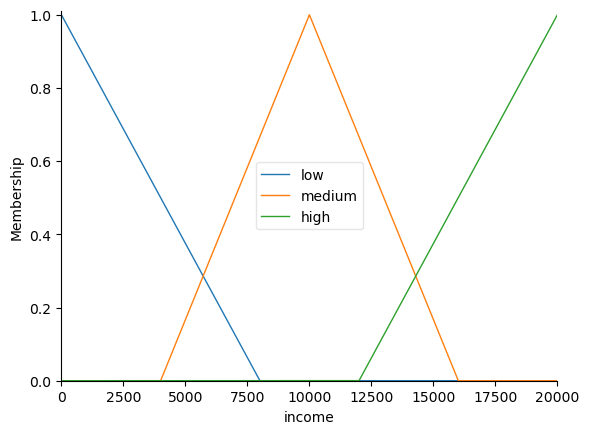

In [49]:
income.view()

In [50]:
credit_score['bad'] = fuzz.trimf(
    credit_score.universe,
    [300, 300, 600]
)

credit_score['average'] = fuzz.trimf(
    credit_score.universe,
    [500, 650, 800]
)

credit_score['good'] = fuzz.trimf(
    credit_score.universe,
    [700, 900, 900]
)

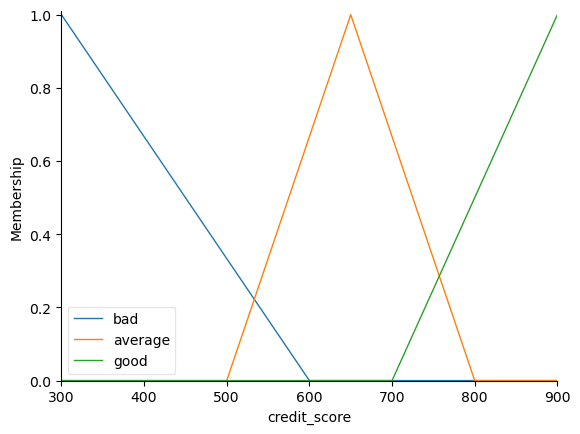

In [51]:
credit_score.view()

In [52]:
risk['high'] = fuzz.trimf(risk.universe, [0, 0, 50])

risk['medium'] = fuzz.trimf(risk.universe, [25, 50, 75])

risk['low'] = fuzz.trimf(risk.universe, [50, 100, 100])

In [53]:
rule1 = ctrl.Rule(
    income['low'] & credit_score['bad'],
    risk['high']
)

rule2 = ctrl.Rule(
    income['medium'] & credit_score['average'],
    risk['medium']
)

rule3 = ctrl.Rule(
    income['high'] & credit_score['good'],
    risk['low']
)

In [54]:
risk_ctrl = ctrl.ControlSystem([
    rule1,
    rule2,
    rule3
])

risk_simulator = ctrl.ControlSystemSimulation(risk_ctrl)

In [55]:
risk_simulator.input['income'] = 12000

risk_simulator.input['credit_score'] = 780

In [56]:
risk_simulator.compute()

In [57]:
print(risk_simulator.output['risk'])

49.99999999999996


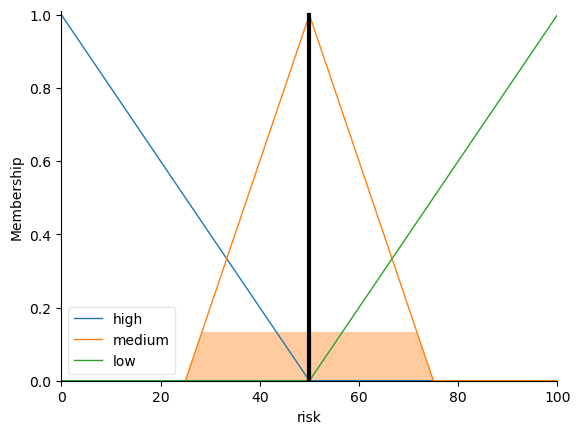

In [58]:
risk.view(sim=risk_simulator)